# Imports

In [2]:
import os, sys, ast
sys.path.append(os.path.abspath(os.path.join('../..')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Aestetic taken from edit_v2_analysis


In [3]:
# Aesthetic seaborn styling - clean with sparse, faint horizontal gridlines
sns.set_theme(style="whitegrid", font_scale=1.1)
sns.set_style({
    "axes.grid": True,
    "axes.grid.axis": "y",  # Only horizontal gridlines
    "grid.linestyle": "-",
    "grid.alpha": 0.25,
    "grid.color": "#e0e0e0",
    "axes.spines.left": False,
    "axes.spines.bottom": True,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.edgecolor": "#333333",
    # "patch.edgecolor": "none"
})
plt.rcParams["axes.axisbelow"] = True  # Grid behind data

# ============================================================
# Color palettes and orders for categorical comparisons
# ============================================================

# Difficulty: intuitive traffic-light progression
DIFFICULTY_ORDER = ["easy", "medium", "hard"]
DIFFICULTY_PALETTE = {"easy": "#4CAF50", "medium": "#FFA726", "hard": "#EF5350"}  # green → orange → red

# Assembly: False=single part (lighter), True=assembly (darker/richer)
ASSEMBLY_ORDER = [False, True]
ASSEMBLY_PALETTE = {False: "#90CAF9", True: "#1565C0"}  # light blue → dark blue

# Parametric: False=direct modeling (lighter), True=parametric (darker/richer)
PARAMETRIC_ORDER = [False, True]
PARAMETRIC_PALETTE = {False: "#CE93D8", True: "#7B1FA2"}  # light purple → dark purple

# Modality: interactive, text, draw-temp, draw-static
MODALITY_ORDER = ["text", "interactive", "draw-temp", "draw-static"]
# orange -> black -> red -> blue
MODALITY_PALETTE = {"interactive": "#FFA500", "text": "#000000", "draw-temp": "#FF5555", "draw-static": "#FF0000"}

USER_ORDER = ["gt_human", "other_human", "claude-sonnet-4.5_cadquery-script", "gemini-3-pro_cadquery-script", "gpt-5.2_cadquery-script"]
USER_PALETTE = {
    "gt_human": "#a0a0a0",   # ligher grey for ground truth human
    "other_human": "#777777",   # grey for other human
    "gpt-5.2_cadquery-script": '#49b599', # "#149e7b",        # teal for gpt-5.2
    "gemini-3-pro_cadquery-script": "#4b85f6",   # blue for gemini
    "claude-sonnet-4.5_cadquery-script": "#D97757" # orange for claude
}

# Use short labels for the x-axis for better readability
short_user_labels = {
    "other_human": "human baseline",
    "gt_human": "requester",
    "gpt-5.2_cadquery-script": "GPT-5.2",
    "gemini-3-pro_cadquery-script": "Gemini-3-Pro",
    "claude-sonnet-4.5_cadquery-script": "Claude-Sonnet-4.5",
}

font_size = 16

ARM_ORDER = ["MCP", "script"]
ARM_PALETTE = {"MCP": "#2a78d6", "script": "#e0701f"}


# load CSV


In [4]:
date = "2026_07_22"
df_edits    = pd.read_csv(f"../../consolidated_data/edits_v2_df_edits_{date}.csv")
df_ratings  = pd.read_csv(f"../../consolidated_data/edits_v2_df_ratings_{date}.csv")
df_requests = pd.read_csv(f"../../consolidated_data/edits_v2_df_requests_{date}.csv")
print(df_edits.shape, df_ratings.shape)


(1344, 62) (12262, 17)


# data processing

In [5]:
# filter out only qwen 
mask = df_edits["user"].str.contains("qwen")
q = df_edits[mask].copy()  


names = {
    "qwen3.6-27b_cadquery-mcp":    "MCP",
    "qwen3.6-27b_cadquery-script": "script",
}
q["arm"] = q["user"].map(names)


# failure if no metric
q["success"] = q["chamfer_similarity"].notna()


# token count
#todo

# graphics


## Success rate

/tmp/ipykernel_119707/1083733803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=succ, x="arm", y="success", order=ARM_ORDER, palette=ARM_PALETTE)


Text(0.5, 0, '')

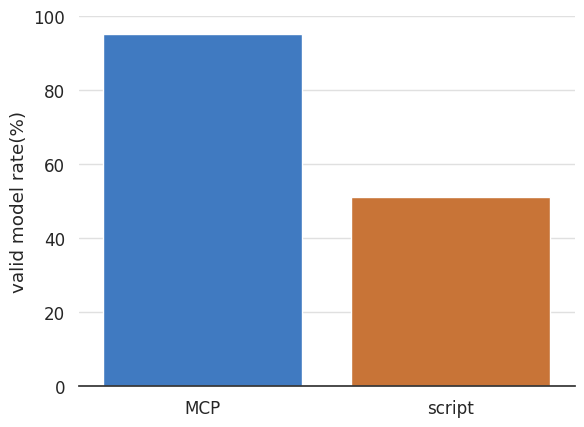

In [6]:
succ = (q.groupby("arm")["success"].mean() * 100).reindex(ARM_ORDER).reset_index()
sns.barplot(data=succ, x="arm", y="success", order=ARM_ORDER, palette=ARM_PALETTE)
plt.ylabel("valid model rate(%)"); plt.ylim(0, 100); plt.xlabel("")


Text(0.5, 0, '')

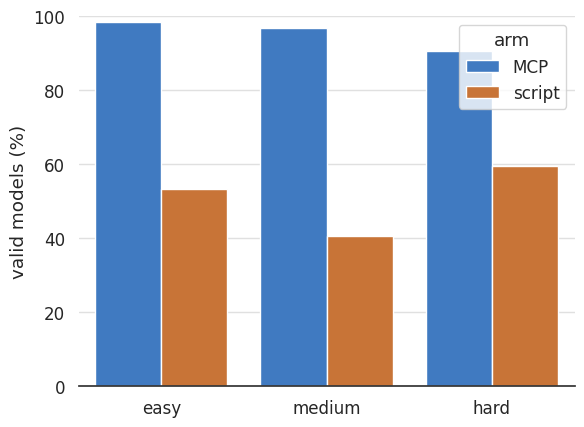

In [10]:
succ_d = (q.groupby(["request_difficulty","arm"])["success"].mean() * 100).reset_index()
sns.barplot(data=succ_d, x="request_difficulty", y="success", hue="arm",
            order=DIFFICULTY_ORDER, hue_order=ARM_ORDER, palette=ARM_PALETTE)
plt.ylabel("valid models (%)"); plt.ylim(0, 100); plt.xlabel("")



In [ ]:
long = q.melt(id_vars=["arm","request_difficulty"],
              value_vars=["chamfer_similarity","iou","dino-v2_similarity"],
              var_name="metric", value_name="score")
sns.catplot(data=long, x="arm", y="score", col="metric", kind="bar",
            estimator=np.median, errorbar=None, order=ARM_ORDER,
            palette=ARM_PALETTE, sharey=False)


NameError: name 'q' is not defined

In [8]:
from scipy.stats import wilcoxon
piv = q.pivot_table(index="request", columns="arm", values="iou").dropna()
stat, p = wilcoxon(piv["MCP"], piv["script"])
print(p)          

0.2488922566467845
